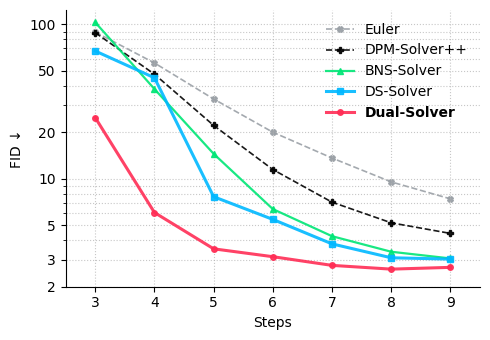

In [7]:
PALETTES = [
    ["#FF2D55", "#00B8FF", "#00E676"],
    ["#1f77b4", "#ff7f0e", "#2ca02c"],  # Classic Blue–Orange–Green
    ["#d62728", "#1f77b4", "#7f7f7f"],  # Muted Red–Blue–Gray
    ["#4c78a8", "#f58518", "#54a24b"],  # Vega-Altair Set
    ["#2b83ba", "#abdda4", "#fdae61"],  # Nature Inspired
    ["#e69f00", "#56b4e9", "#009e73"],  # CUD (color-blind friendly)
    ["#377eb8", "#e41a1c", "#4d4d4d"],  # Cool–Warm–Neutral
    ["#8c510a", "#01665e", "#f5f5f5"],  # Earth Tone
    ["#e41a1c", "#377eb8", "#4daf4a"],  # Bold & Bright
    ["#984ea3", "#ff7f00", "#66a61e"],  # Dark Pastel
    ["#000000", "#7f7f7f", "#e6e6e6"],  # Grayscale Emphasis
]

# Apply: DPM-Solver++ = black, Euler = gray. Others unchanged (neon).
# Dual (ours) bold; DS/BNS medium; DPM/Euler dashed.

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import numpy as np

steps = np.array([3, 4, 5, 6, 7, 8, 9])
results = {
    "Euler":          np.array([89.33, 56.33, 32.91, 20.05, 13.64,  9.55,  7.42]),
    "DPM-Solver++":   np.array([88.46, 47.64, 22.19, 11.49,  7.06,  5.19,  4.43]),
    "BNS-Solver":     np.array([103.26, 38.20, 14.53,  6.37,  4.25,  3.37,  3.05]),
    "DS-Solver":      np.array([ 67.31, 45.16,  7.66,  5.46,  3.79,  3.08,  3.02]),
    "Dual-Solver":    np.array([ 24.91,  6.05,  3.52,  3.13,  2.75,  2.60,  2.67]),  # 첫 값 24.91 확인 필요(다시?)
}

style = {
    "Dual-Solver": dict(color=PALETTES[0][0], lw=2.2, ls="-",  marker="o", zorder=5),
    "DS-Solver": dict(color=PALETTES[0][1], lw=2.2, ls="-",  marker="s", zorder=4),
    "BNS-Solver":      dict(color=PALETTES[0][2], lw=1.6, ls="-",  marker="^", zorder=3),
    "DPM-Solver++":   dict(color="#000000", lw=1.2, ls="--", marker="P", zorder=2),  # black
    "Euler":          dict(color="#9AA0A6", lw=1.2, ls="--", marker="X", zorder=1),  # gray
}

fig, ax = plt.subplots(figsize=(5, 3.5))
lines = {}

for label, vals in results.items():
    st = style[label]
    (line,) = ax.plot(
        steps, vals,
        label=label, marker=st["marker"], linewidth=st["lw"],
        linestyle=st["ls"], color=st["color"], markersize=4, zorder=st["zorder"], alpha=0.9
    )
    lines[label] = line

ax.set_xlabel("Steps")
ax.set_ylabel("FID ↓")
ax.set_xticks(steps)
ax.set_xlim(2.5, 9.5)
ax.set_yscale("log")
yticks = [2, 3, 5, 10, 20, 50, 100]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _ : f"{y:g}"))
ax.yaxis.set_minor_formatter(NullFormatter())
ax.grid(True, which="both", linestyle=":", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(handles=[lines[k] for k in results.keys()], frameon=False, loc="upper right")
for txt in leg.get_texts():
    if txt.get_text().startswith("Dual-Solver"):
        txt.set_fontweight("bold")

fig.tight_layout()
plt.show()
